# Platooning and Regular Rest

This notebook looks for players who are not quite everyday starters by combining the scraped batting-order files with scheduled opposing starter context and FanGraphs pitcher handedness.

The core idea is to summarize, for every player on every team:

- how often he starts during his observed active window
- whether missed starts are isolated rest days or longer absences
- how regular the spacing of missed starts looks
- whether recent usage differs from season-to-date usage
- how stable his lineup spot is when he does start
- which opposing starter was scheduled when he sat
- whether his starts/sits cluster against left- or right-handed starters

In [1]:
from __future__ import annotations

import os
from functools import lru_cache
from io import StringIO
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', str(Path('/tmp') / 'batting-order-matplotlib'))
os.environ.setdefault('XDG_CACHE_HOME', str(Path('/tmp') / 'batting-order-cache'))

import numpy as np
import pandas as pd
import requests

import mlbstatscraping as ss

In [2]:
YEAR = '2026'
OUTDIR = ''
DATA_ROOT = Path('../../data')
RECENT_WINDOW = 14
MIN_ACTIVE_GAMES = 10
MIN_HANDEDNESS_GAMES = 5
PLATOON_GAP_THRESHOLD = 0.25
PREDICTIONS_BASE_URL = 'https://raw.githubusercontent.com/fantasy-toolz/mlb-predictions/refs/heads/main/data'

ALL_TEAMS = [
    'LAA', 'HOU', 'ATH', 'TOR', 'ATL', 'MIL', 'STL', 'CHC', 'AZ', 'LAD',
    'SF', 'CLE', 'SEA', 'MIA', 'NYM', 'WSH', 'BAL', 'SD', 'PHI', 'PIT',
    'TEX', 'TB', 'BOS', 'CIN', 'COL', 'KC', 'DET', 'MIN', 'CWS', 'NYY',
]

TEAMS = ALL_TEAMS

In [3]:
LINEUP_COLS = [f'lineup{i}' for i in range(1, 10)]


def normalize_name(name: object) -> str:
    if pd.isna(name):
        return ''
    return ' '.join(str(name).strip().casefold().replace('.', '').split())


def canonical_throws(value: object) -> str | float:
    if pd.isna(value):
        return np.nan
    value = str(value).strip().upper()
    if value.startswith('L'):
        return 'L'
    if value.startswith('R'):
        return 'R'
    return np.nan


def lineup_path(team: str, year: str = YEAR, outdir: str = OUTDIR) -> Path:
    return DATA_ROOT / outdir / year / f'{team}.csv'


def read_team_lineups(team: str, year: str = YEAR, outdir: str = OUTDIR) -> pd.DataFrame:
    df = pd.read_csv(lineup_path(team, year, outdir))
    unnamed_cols = [col for col in df.columns if str(col).startswith('Unnamed')]
    if unnamed_cols:
        df = df.drop(columns=unnamed_cols)

    df['team'] = team
    df['team_game'] = np.arange(len(df))
    df['date'] = df['date'].astype(str)
    df['date_base'] = df['date'].str.replace(r'[ab]$', '', regex=True)
    df['date_suffix'] = df['date'].str.extract(r'([ab])$', expand=False).fillna('')

    for col in LINEUP_COLS:
        df[col] = df[col].astype('string').str.strip()

    return df


def prediction_url(team: str, year: str = YEAR) -> str:
    return f'{PREDICTIONS_BASE_URL}/{year}/teams/{team}.csv'


def read_team_predictions(team: str, year: str = YEAR) -> pd.DataFrame:
    response = requests.get(prediction_url(team, year), timeout=30)
    response.raise_for_status()
    predictions = pd.read_csv(StringIO(response.text))
    predictions['date'] = predictions['date'].astype(str)
    predictions['date_base'] = predictions['date'].str.replace(r'[ab]$', '', regex=True)
    predictions['date_order'] = predictions.groupby('date_base').cumcount()

    keep_cols = [
        'date_base',
        'date_order',
        'opponent',
        'teamstarter',
        'opponentstarter',
    ]
    return predictions[keep_cols]


@lru_cache(maxsize=8)
def load_pitching_handedness(year: str = YEAR) -> pd.DataFrame:
    pitching = ss.get_fangraphs_data('pitching', [year], advanced=True)
    pitching = pitching.copy()
    pitching['Name'] = pitching['Name'].astype(str).str.strip()
    pitching['name_key'] = pitching['Name'].map(normalize_name)
    if 'Throws' not in pitching.columns:
        pitching['Throws'] = np.nan
    pitching['fangraphs_throws'] = pitching['Throws'].map(canonical_throws)
    return pitching.dropna(subset=['name_key'])


@lru_cache(maxsize=32)
def fetch_mlb_pitcher_hands(player_ids: tuple[int, ...]) -> pd.DataFrame:
    ids = tuple(sorted({int(player_id) for player_id in player_ids if pd.notna(player_id)}))
    if not ids:
        return pd.DataFrame(columns=['pitcher_mlbam_id', 'mlb_pitcher_throws'])

    rows: list[dict[str, object]] = []
    chunk_size = 100
    for start in range(0, len(ids), chunk_size):
        chunk = ids[start:start + chunk_size]
        response = requests.get(
            'https://statsapi.mlb.com/api/v1/people',
            params={'personIds': ','.join(str(player_id) for player_id in chunk)},
            timeout=30,
        )
        response.raise_for_status()
        for person in response.json().get('people', []):
            rows.append({
                'pitcher_mlbam_id': person.get('id'),
                'mlb_pitcher_throws': canonical_throws(person.get('pitchHand', {}).get('code')),
            })

    return pd.DataFrame(rows)


def get_pitcher_match(name: object, pitching: pd.DataFrame | None = None) -> pd.Series:
    if pitching is None:
        pitching = load_pitching_handedness()

    lookup = normalize_name(name)
    if not lookup:
        return pd.Series({
            'pitcher_match_name': np.nan,
            'pitcher_mlbam_id': np.nan,
            'fangraphs_throws': np.nan,
            'pitcher_match_type': 'missing_name',
            'pitcher_match_count': 0,
        })

    exact = pitching.loc[pitching['name_key'] == lookup]
    if not exact.empty:
        match = exact.sort_values('Year').iloc[-1] if 'Year' in exact.columns else exact.iloc[-1]
        return pd.Series({
            'pitcher_match_name': match['Name'],
            'pitcher_mlbam_id': match.get('xMLBAMID', np.nan),
            'fangraphs_throws': match.get('fangraphs_throws', np.nan),
            'pitcher_match_type': 'exact',
            'pitcher_match_count': len(exact),
        })

    partial = pitching.loc[pitching['name_key'].str.contains(lookup, regex=False, na=False)]
    if len(lookup) >= 5 and not partial.empty:
        if partial['Name'].nunique() == 1:
            match = partial.sort_values('Year').iloc[-1] if 'Year' in partial.columns else partial.iloc[-1]
            return pd.Series({
                'pitcher_match_name': match['Name'],
                'pitcher_mlbam_id': match.get('xMLBAMID', np.nan),
                'fangraphs_throws': match.get('fangraphs_throws', np.nan),
                'pitcher_match_type': 'partial',
                'pitcher_match_count': len(partial),
            })
        return pd.Series({
            'pitcher_match_name': ', '.join(sorted(partial['Name'].unique())[:5]),
            'pitcher_mlbam_id': np.nan,
            'fangraphs_throws': np.nan,
            'pitcher_match_type': 'ambiguous_partial',
            'pitcher_match_count': len(partial),
        })

    return pd.Series({
        'pitcher_match_name': np.nan,
        'pitcher_mlbam_id': np.nan,
        'fangraphs_throws': np.nan,
        'pitcher_match_type': 'unmatched',
        'pitcher_match_count': 0,
    })


def get_pitcher_handedness(name: object, pitching: pd.DataFrame | None = None) -> pd.Series:
    match = get_pitcher_match(name, pitching)
    throws = match['fangraphs_throws']
    if pd.isna(throws) and pd.notna(match['pitcher_mlbam_id']):
        hand_lookup = fetch_mlb_pitcher_hands((int(match['pitcher_mlbam_id']),))
        if not hand_lookup.empty:
            throws = hand_lookup['mlb_pitcher_throws'].iloc[0]

    return pd.Series({
        'pitcher_match_name': match['pitcher_match_name'],
        'pitcher_throws': throws,
        'pitcher_match_type': match['pitcher_match_type'],
        'pitcher_match_count': match['pitcher_match_count'],
    })


def add_pitcher_handedness(
    df: pd.DataFrame,
    pitcher_col: str = 'opponentstarter',
    prefix: str = 'opponentstarter',
    pitching: pd.DataFrame | None = None,
) -> pd.DataFrame:
    if pitching is None:
        pitching = load_pitching_handedness()

    contextual = df.copy()
    unique_pitchers = pd.Series(contextual[pitcher_col].dropna().unique(), name=pitcher_col)
    if unique_pitchers.empty:
        contextual[f'{prefix}_match_name'] = np.nan
        contextual[f'{prefix}_throws'] = np.nan
        contextual[f'{prefix}_match_type'] = np.nan
        contextual[f'{prefix}_match_count'] = 0
        return contextual

    lookup = unique_pitchers.apply(lambda name: get_pitcher_match(name, pitching))
    lookup[pitcher_col] = unique_pitchers.values

    matched_ids = tuple(
        int(player_id)
        for player_id in lookup['pitcher_mlbam_id'].dropna().unique()
    )
    mlb_hands = fetch_mlb_pitcher_hands(matched_ids)
    if not mlb_hands.empty:
        lookup = lookup.merge(mlb_hands, on='pitcher_mlbam_id', how='left')
    else:
        lookup['mlb_pitcher_throws'] = np.nan

    lookup['pitcher_throws'] = lookup['fangraphs_throws'].combine_first(lookup['mlb_pitcher_throws'])
    lookup = lookup.rename(columns={
        'pitcher_match_name': f'{prefix}_match_name',
        'pitcher_throws': f'{prefix}_throws',
        'pitcher_match_type': f'{prefix}_match_type',
        'pitcher_match_count': f'{prefix}_match_count',
    })
    keep_cols = [
        pitcher_col,
        f'{prefix}_match_name',
        f'{prefix}_throws',
        f'{prefix}_match_type',
        f'{prefix}_match_count',
    ]

    return contextual.merge(lookup[keep_cols], on=pitcher_col, how='left')


def add_pitcher_context(
    df: pd.DataFrame,
    team: str,
    year: str = YEAR,
    include_handedness: bool = False,
) -> pd.DataFrame:
    predictions = read_team_predictions(team, year)
    contextual = df.copy()
    contextual['date_order'] = contextual.groupby('date_base').cumcount()
    contextual = contextual.merge(
        predictions,
        on=['date_base', 'date_order'],
        how='left',
        validate='one_to_one',
    )

    if include_handedness:
        contextual = add_pitcher_handedness(contextual, 'opponentstarter', 'opponentstarter')

    return contextual


def lineup_long(df: pd.DataFrame) -> pd.DataFrame:
    long = df.melt(
        id_vars=['team', 'team_game', 'date', 'date_base', 'date_suffix'],
        value_vars=LINEUP_COLS,
        var_name='lineup_slot',
        value_name='player',
    )
    long = long.dropna(subset=['player'])
    long = long[long['player'] != '']
    long['lineup_spot'] = long['lineup_slot'].str.extract(r'(\d+)').astype(int)
    return long.drop(columns=['lineup_slot'])


def consecutive_true_runs(mask: np.ndarray) -> list[tuple[int, int, int]]:
    runs: list[tuple[int, int, int]] = []
    start: int | None = None

    for idx, value in enumerate(mask):
        if value and start is None:
            start = idx
        elif not value and start is not None:
            runs.append((start, idx - 1, idx - start))
            start = None

    if start is not None:
        runs.append((start, len(mask) - 1, len(mask) - start))

    return runs


def mode_or_nan(values: pd.Series) -> float:
    modes = values.mode(dropna=True)
    if modes.empty:
        return np.nan
    return float(modes.iloc[0])

In [4]:
def handedness_split_metrics(active_df: pd.DataFrame, active_starts: np.ndarray) -> dict[str, object]:
    metrics: dict[str, object] = {
        'games_vs_lhp': np.nan,
        'starts_vs_lhp': np.nan,
        'sits_vs_lhp': np.nan,
        'start_pct_vs_lhp': np.nan,
        'games_vs_rhp': np.nan,
        'starts_vs_rhp': np.nan,
        'sits_vs_rhp': np.nan,
        'start_pct_vs_rhp': np.nan,
        'platoon_start_pct_gap': np.nan,
    }
    if 'opponentstarter_throws' not in active_df.columns:
        return metrics

    split_df = active_df[['opponentstarter_throws']].copy()
    split_df['started'] = active_starts.astype(int)
    split_df = split_df.dropna(subset=['opponentstarter_throws'])

    for throws, suffix in [('L', 'lhp'), ('R', 'rhp')]:
        subset = split_df[split_df['opponentstarter_throws'] == throws]
        games = len(subset)
        starts = int(subset['started'].sum()) if games else 0
        metrics[f'games_vs_{suffix}'] = games
        metrics[f'starts_vs_{suffix}'] = starts
        metrics[f'sits_vs_{suffix}'] = games - starts
        metrics[f'start_pct_vs_{suffix}'] = starts / games if games else np.nan

    if metrics['games_vs_lhp'] >= MIN_HANDEDNESS_GAMES and metrics['games_vs_rhp'] >= MIN_HANDEDNESS_GAMES:
        metrics['platoon_start_pct_gap'] = metrics['start_pct_vs_rhp'] - metrics['start_pct_vs_lhp']

    return metrics


def classify_usage(row: pd.Series) -> str:
    if row['active_games'] < MIN_ACTIVE_GAMES:
        return 'small_sample'
    if abs(row.get('platoon_start_pct_gap', np.nan)) >= PLATOON_GAP_THRESHOLD:
        return 'platoon_candidate'
    if row['start_pct'] >= 0.90:
        return 'everyday'
    if row['recent_start_pct'] <= row['start_pct'] - 0.25 and row['recent_games'] >= 7:
        return 'losing_time'
    if row['longest_missed_run'] >= 5:
        return 'extended_absence_candidate'
    if (
        0.55 <= row['start_pct'] < 0.90
        and row['missed_episodes'] >= 3
        and row['median_rest_gap'] <= 7
        and row['rest_gap_cv'] <= 0.80
    ):
        return 'regular_rest'
    if 0.35 <= row['start_pct'] < 0.75:
        return 'part_time_or_rotation'
    if row['start_pct'] < 0.35:
        return 'bench_or_short_side'
    return 'irregular_rest'


def summarize_team_usage(df: pd.DataFrame, recent_window: int = RECENT_WINDOW) -> pd.DataFrame:
    long = lineup_long(df)
    players = sorted(long['player'].unique())
    rows: list[dict[str, object]] = []

    for player in players:
        starts_by_game = df[LINEUP_COLS].eq(player).any(axis=1).to_numpy()
        start_indices = np.flatnonzero(starts_by_game)
        if len(start_indices) == 0:
            continue

        first_game = int(start_indices[0])
        last_game = int(start_indices[-1])
        active_slice = slice(first_game, last_game + 1)
        active_df = df.iloc[active_slice].copy()
        active_starts = starts_by_game[active_slice]
        active_games = len(active_starts)
        active_start_count = int(active_starts.sum())
        missed_mask = ~active_starts
        missed_runs = consecutive_true_runs(missed_mask)
        missed_run_starts = np.array([run[0] for run in missed_runs], dtype=float)
        rest_gaps = np.diff(missed_run_starts) if len(missed_run_starts) > 1 else np.array([])

        recent_starts = active_starts[-recent_window:]
        player_spots = long.loc[long['player'] == player, 'lineup_spot']

        row = {
            'team': df['team'].iloc[0],
            'player': player,
            'first_date': df.loc[first_game, 'date'],
            'last_date': df.loc[last_game, 'date'],
            'active_games': active_games,
            'starts': active_start_count,
            'missed_starts': int(missed_mask.sum()),
            'start_pct': active_start_count / active_games,
            'recent_games': len(recent_starts),
            'recent_starts': int(recent_starts.sum()),
            'recent_start_pct': float(recent_starts.mean()) if len(recent_starts) else np.nan,
            'missed_episodes': len(missed_runs),
            'single_game_rests': sum(run[2] == 1 for run in missed_runs),
            'multi_game_absences': sum(run[2] > 1 for run in missed_runs),
            'longest_missed_run': max((run[2] for run in missed_runs), default=0),
            'median_rest_gap': float(np.median(rest_gaps)) if len(rest_gaps) else np.nan,
            'mean_rest_gap': float(np.mean(rest_gaps)) if len(rest_gaps) else np.nan,
            'rest_gap_cv': float(np.std(rest_gaps) / np.mean(rest_gaps)) if len(rest_gaps) and np.mean(rest_gaps) else np.nan,
            'avg_lineup_spot': float(player_spots.mean()),
            'median_lineup_spot': float(player_spots.median()),
            'mode_lineup_spot': mode_or_nan(player_spots),
            'lineup_spot_std': float(player_spots.std()) if len(player_spots) > 1 else 0.0,
        }
        row.update(handedness_split_metrics(active_df, active_starts))
        rows.append(row)

    summary = pd.DataFrame(rows)
    if summary.empty:
        return summary

    summary['usage_label'] = summary.apply(classify_usage, axis=1)
    return summary.sort_values(['team', 'start_pct', 'starts'], ascending=[True, False, False]).reset_index(drop=True)


def player_handedness_table(df: pd.DataFrame, player: str) -> pd.DataFrame:
    if 'opponentstarter_throws' not in df.columns:
        return pd.DataFrame()

    starts_by_game = df[LINEUP_COLS].eq(player).any(axis=1).to_numpy()
    start_indices = np.flatnonzero(starts_by_game)
    if len(start_indices) == 0:
        return pd.DataFrame()

    first_game = int(start_indices[0])
    last_game = int(start_indices[-1])
    active_df = df.iloc[first_game:last_game + 1].copy()
    active_df['started'] = starts_by_game[first_game:last_game + 1].astype(int)
    active_df = active_df.dropna(subset=['opponentstarter_throws'])

    rows = []
    for throws, label in [('L', 'vs_lhp'), ('R', 'vs_rhp')]:
        subset = active_df[active_df['opponentstarter_throws'] == throws]
        if subset.empty:
            continue
        sits = subset[subset['started'] == 0]
        rows.append({
            'split': label,
            'games': len(subset),
            'starts': int(subset['started'].sum()),
            'sits': int((subset['started'] == 0).sum()),
            'start_pct': subset['started'].mean(),
            'sit_pct': 1 - subset['started'].mean(),
            'opposing_starters_when_sitting': ', '.join(sits['opponentstarter'].dropna().astype(str).unique()[:12]),
        })
    return pd.DataFrame(rows)


def missed_start_table(df: pd.DataFrame, player: str) -> pd.DataFrame:
    starts_by_game = df[LINEUP_COLS].eq(player).any(axis=1).to_numpy()
    start_indices = np.flatnonzero(starts_by_game)
    if len(start_indices) == 0:
        return pd.DataFrame()

    first_game = int(start_indices[0])
    last_game = int(start_indices[-1])
    active_df = df.iloc[first_game:last_game + 1].copy()
    missed = active_df.loc[~starts_by_game[first_game:last_game + 1]].copy()
    missed['player'] = player

    context_cols = [
        'player',
        'team',
        'team_game',
        'date',
        'opponent',
        'teamstarter',
        'opponentstarter',
        'opponentstarter_throws',
        'opponentstarter_match_name',
        'opponentstarter_match_type',
    ]
    available_cols = [col for col in context_cols if col in missed.columns]
    return missed[available_cols].reset_index(drop=True)


def missed_episode_table(df: pd.DataFrame, player: str) -> pd.DataFrame:
    starts_by_game = df[LINEUP_COLS].eq(player).any(axis=1).to_numpy()
    start_indices = np.flatnonzero(starts_by_game)
    if len(start_indices) == 0:
        return pd.DataFrame()

    first_game = int(start_indices[0])
    last_game = int(start_indices[-1])
    active_df = df.iloc[first_game:last_game + 1].reset_index(drop=True)
    missed_runs = consecutive_true_runs(~starts_by_game[first_game:last_game + 1])

    rows: list[dict[str, object]] = []
    for start, end, length in missed_runs:
        run_df = active_df.loc[start:end]
        row = {
            'player': player,
            'start_date': active_df.loc[start, 'date'],
            'end_date': active_df.loc[end, 'date'],
            'length': length,
            'first_team_game': int(active_df.loc[start, 'team_game']),
            'last_team_game': int(active_df.loc[end, 'team_game']),
        }
        if 'opponentstarter' in run_df.columns:
            row['opposing_starters'] = ', '.join(run_df['opponentstarter'].dropna().astype(str))
        if 'opponentstarter_throws' in run_df.columns:
            row['opposing_starter_throws'] = ', '.join(run_df['opponentstarter_throws'].dropna().astype(str))
        if 'opponent' in run_df.columns:
            row['opponents'] = ', '.join(run_df['opponent'].dropna().astype(str))
        rows.append(row)

    return pd.DataFrame(rows)

In [5]:
def replacement_candidates(df: pd.DataFrame, player: str, top_n: int = 12) -> pd.DataFrame:
    long = lineup_long(df)
    player_rows = long[long['player'] == player]
    if player_rows.empty:
        return pd.DataFrame()

    starts_by_game = df[LINEUP_COLS].eq(player).any(axis=1).to_numpy()
    start_indices = np.flatnonzero(starts_by_game)
    first_game = int(start_indices[0])
    last_game = int(start_indices[-1])
    active_games = set(range(first_game, last_game + 1))
    missed_games = {idx for idx in active_games if not starts_by_game[idx]}

    common_spots = player_rows['lineup_spot'].value_counts().head(3).index.tolist()
    replacements = long[
        long['team_game'].isin(missed_games)
        & long['lineup_spot'].isin(common_spots)
        & (long['player'] != player)
    ]

    if replacements.empty:
        return pd.DataFrame()

    counts = (
        replacements
        .groupby(['player', 'lineup_spot'])
        .size()
        .rename('starts_in_player_common_slots')
        .reset_index()
        .sort_values('starts_in_player_common_slots', ascending=False)
    )
    return counts.head(top_n).reset_index(drop=True)


def player_usage_frame(df: pd.DataFrame, player: str, recent_window: int = RECENT_WINDOW) -> pd.DataFrame:
    starts = df[LINEUP_COLS].eq(player).any(axis=1)
    spots = []
    for _, row in df.iterrows():
        spot = np.nan
        for idx, col in enumerate(LINEUP_COLS, start=1):
            if row[col] == player:
                spot = idx
                break
        spots.append(spot)

    usage = df[['team', 'team_game', 'date']].copy()
    usage['started'] = starts.astype(int)
    usage['lineup_spot'] = spots
    usage['rolling_start_pct'] = usage['started'].rolling(recent_window, min_periods=1).mean()
    if 'opponentstarter_throws' in df.columns:
        usage['opponentstarter_throws'] = df['opponentstarter_throws']
    return usage


def plot_player_usage(df: pd.DataFrame, player: str, recent_window: int = RECENT_WINDOW) -> None:
    import matplotlib.pyplot as plt

    usage = player_usage_frame(df, player, recent_window)
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True, height_ratios=[1.3, 1])

    colors = {'L': 'tab:red', 'R': 'tab:blue'}
    if 'opponentstarter_throws' in usage.columns:
        for throws, color in colors.items():
            split = usage[usage['opponentstarter_throws'] == throws]
            axes[0].scatter(split['team_game'], split['started'], color=color, s=22, alpha=0.65, label=f'vs {throws}HP')
        axes[0].legend(loc='lower left')
    else:
        axes[0].scatter(usage['team_game'], usage['started'], color='black', s=18, alpha=0.55)

    axes[0].plot(usage['team_game'], usage['rolling_start_pct'], color='black', linewidth=2)
    axes[0].set_ylim(-0.05, 1.05)
    axes[0].set_ylabel('Start rate')
    axes[0].set_title(f'{player}: starts and {recent_window}-game rolling start rate')

    started_usage = usage[usage['started'] == 1]
    axes[1].scatter(started_usage['team_game'], started_usage['lineup_spot'], color='tab:green', s=28)
    axes[1].invert_yaxis()
    axes[1].set_yticks(range(1, 10))
    axes[1].set_xlabel('Team game')
    axes[1].set_ylabel('Lineup spot')

    plt.tight_layout()

In [6]:
team_games = {team: read_team_lineups(team) for team in TEAMS}
usage_summary = pd.concat(
    [summarize_team_usage(df) for df in team_games.values()],
    ignore_index=True,
)

usage_summary.head(20)

,team,player,first_date,last_date,active_games,starts,missed_starts,start_pct,recent_games,recent_starts,...,games_vs_lhp,starts_vs_lhp,sits_vs_lhp,start_pct_vs_lhp,games_vs_rhp,starts_vs_rhp,sits_vs_rhp,start_pct_vs_rhp,platoon_start_pct_gap,usage_label
0,LAA,Omar Martinez,2026-05-12,2026-05-12,1,1,0,1.000000,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,small_sample
1,LAA,Mike Trout,2026-03-26,2026-06-17,75,74,1,0.986667,14,14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,everyday
2,LAA,Jo Adell,2026-03-26,2026-07-02,88,86,2,0.977273,14,13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,everyday
3,LAA,Zach Neto,2026-03-26,2026-07-02,88,84,4,0.954545,14,13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,everyday
4,LAA,Denzer Guzman,2026-06-08,2026-07-02,22,19,3,0.863636,14,12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,irregular_rest
5,LAA,Wade Meckler,2026-05-22,2026-07-02,37,31,6,0.837838,14,12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,regular_rest
6,LAA,Nolan Schanuel,2026-03-26,2026-07-02,88,67,21,0.761364,14,12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,extended_absence_candidate
7,LAA,Trey Mancini,2026-06-08,2026-06-12,4,3,1,0.750000,4,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,small_sample
8,LAA,Jorge Soler,2026-03-26,2026-07-02,88,65,23,0.738636,14,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,extended_absence_candidate
9,LAA,Christian Moore,2026-06-18,2026-06-24,7,5,2,0.714286,7,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,small_sample


In [7]:
def build_handedness_usage_summary(
    team_frames: dict[str, pd.DataFrame],
    teams: list[str] | None = None,
) -> tuple[pd.DataFrame, dict[str, pd.DataFrame]]:
    teams = teams or list(team_frames)
    enriched_games: dict[str, pd.DataFrame] = {}
    summaries: list[pd.DataFrame] = []

    for team in teams:
        enriched = add_pitcher_context(team_frames[team], team, include_handedness=True)
        enriched_games[team] = enriched
        summaries.append(summarize_team_usage(enriched))

    return pd.concat(summaries, ignore_index=True), enriched_games


# Full all-team handedness scan, intentionally left opt-in because it fetches remote data.
# handedness_usage_summary, team_games_with_handedness = build_handedness_usage_summary(team_games)


In [8]:
flagged_usage = usage_summary[
    usage_summary['usage_label'].isin([
        'regular_rest',
        'platoon_candidate',
        'losing_time',
        'extended_absence_candidate',
        'part_time_or_rotation',
    ])
].copy()

flagged_usage.sort_values(
    ['usage_label', 'team', 'start_pct', 'recent_start_pct'],
    ascending=[True, True, False, True],
).head(50)

,team,player,first_date,last_date,active_games,starts,missed_starts,start_pct,recent_games,recent_starts,...,games_vs_lhp,starts_vs_lhp,sits_vs_lhp,start_pct_vs_lhp,games_vs_rhp,starts_vs_rhp,sits_vs_rhp,start_pct_vs_rhp,platoon_start_pct_gap,usage_label
59,ATH,Brent Rooker,2026-03-27,2026-06-08,66,47,19,0.712121,14,11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,extended_absence_candidate
61,ATH,Jacob Wilson,2026-03-27,2026-06-24,80,50,30,0.625000,14,11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,extended_absence_candidate
63,ATH,Darell Hernaiz,2026-03-29,2026-06-06,62,36,26,0.580645,14,11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,extended_absence_candidate
65,ATH,Alika Williams,2026-05-24,2026-07-01,35,17,18,0.485714,14,7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,extended_absence_candidate
66,ATH,Max Muncy,2026-03-27,2026-06-30,86,41,45,0.476744,14,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,extended_absence_candidate
67,ATH,Jonah Heim,2026-05-06,2026-07-01,52,23,29,0.442308,14,11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,extended_absence_candidate
68,ATH,Colby Thomas,2026-04-25,2026-07-01,61,22,39,0.360656,14,7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,extended_absence_candidate
69,ATH,Austin Wynns,2026-03-29,2026-05-05,33,10,23,0.303030,14,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,extended_absence_candidate
70,ATH,Andy Ibanez,2026-03-31,2026-04-19,18,4,14,0.222222,14,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,extended_absence_candidate
99,ATL,Ronald Acuna Jr.,2026-03-27,2026-06-09,67,53,14,0.791045,14,14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,extended_absence_candidate


In [9]:
team_rollup = (
    usage_summary
    .query('active_games >= @MIN_ACTIVE_GAMES')
    .groupby(['team', 'usage_label'])
    .size()
    .rename('players')
    .reset_index()
    .pivot(index='team', columns='usage_label', values='players')
    .fillna(0)
    .astype(int)
)

team_rollup

usage_label,bench_or_short_side,everyday,extended_absence_candidate,irregular_rest,losing_time,part_time_or_rotation,regular_rest
team,,,,,,,
ATH,0,3,9,1,0,0,5
ATL,0,4,8,1,0,2,2
AZ,0,5,8,1,1,1,4
BAL,0,3,7,0,1,0,5
BOS,0,4,5,3,0,2,3
CHC,0,6,6,1,0,0,1
CIN,0,2,7,3,1,0,5
CLE,0,4,5,2,1,3,5
COL,0,1,6,2,0,1,7


In [10]:
TEAM = 'MIN'
PLAYER = 'Kody Clemens'

team_df = add_pitcher_context(team_games[TEAM], TEAM, include_handedness=True)
team_usage_with_handedness = summarize_team_usage(team_df)
player_row = team_usage_with_handedness.query('team == @TEAM and player == @PLAYER')
player_row

/opt/homebrew/lib/python3.11/site-packages/fangraphs/fangraphsscraper.py:238: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Year'] = year


,team,player,first_date,last_date,active_games,starts,missed_starts,start_pct,recent_games,recent_starts,...,games_vs_lhp,starts_vs_lhp,sits_vs_lhp,start_pct_vs_lhp,games_vs_rhp,starts_vs_rhp,sits_vs_rhp,start_pct_vs_rhp,platoon_start_pct_gap,usage_label
5,MIN,Kody Clemens,2026-03-28,2026-07-01,87,68,19,0.781609,14,13,...,25,8,17,0.32,62,60,2,0.967742,0.647742,platoon_candidate


In [11]:
player_handedness_table(team_df, PLAYER)

,split,games,starts,sits,start_pct,sit_pct,opposing_starters_when_sitting
0,vs_lhp,25,8,17,0.320000,0.680000,"Kris Bubic, Noah Cameron, Steven Matz, Tarik S..."
1,vs_rhp,62,60,2,0.967742,0.032258,"Casey Mize, Erick Fedde"


In [12]:
missed_start_table(team_df, PLAYER)

,player,team,team_game,date,opponent,teamstarter,opponentstarter,opponentstarter_throws,opponentstarter_match_name,opponentstarter_match_type
0,Kody Clemens,MIN,3,2026-03-30,KC,Simeon Woods,Kris Bubic,L,Kris Bubic,exact
1,Kody Clemens,MIN,4,2026-04-01,KC,Joe Ryan,Noah Cameron,L,Noah Cameron,exact
2,Kody Clemens,MIN,7,2026-04-04,TB,Mick Abel,Steven Matz,L,Steven Matz,exact
3,Kody Clemens,MIN,9,2026-04-06,DET,Joe Ryan,Casey Mize,R,Casey Mize,exact
4,Kody Clemens,MIN,10,2026-04-07,DET,Taj Bradley,Tarik Skubal,L,Tarik Skubal,exact
5,Kody Clemens,MIN,11,2026-04-08,DET,Bailey Ober,Framber Valdez,L,Framber Valdez,exact
6,Kody Clemens,MIN,13,2026-04-10,TOR,Simeon Woods,Patrick Corbin,L,Patrick Corbin,exact
7,Kody Clemens,MIN,14,2026-04-11,TOR,Joe Ryan,Eric Lauer,L,Eric Lauer,exact
8,Kody Clemens,MIN,16,2026-04-13,BOS,Bailey Ober,Garrett Crochet,L,Garrett Crochet,exact
9,Kody Clemens,MIN,18,2026-04-15,BOS,Simeon Woods,Connelly Early,L,Connelly Early,exact


In [13]:
missed_episode_table(team_df, PLAYER)

,player,start_date,end_date,length,first_team_game,last_team_game,opposing_starters,opposing_starter_throws,opponents
0,Kody Clemens,2026-03-30,2026-04-01,2,3,4,"Kris Bubic, Noah Cameron","L, L","KC, KC"
1,Kody Clemens,2026-04-04,2026-04-04,1,7,7,Steven Matz,L,TB
2,Kody Clemens,2026-04-06,2026-04-08,3,9,11,"Casey Mize, Tarik Skubal, Framber Valdez","R, L, L","DET, DET, DET"
3,Kody Clemens,2026-04-10,2026-04-11,2,13,14,"Patrick Corbin, Eric Lauer","L, L","TOR, TOR"
4,Kody Clemens,2026-04-13,2026-04-13,1,16,16,Garrett Crochet,L,BOS
5,Kody Clemens,2026-04-15,2026-04-18,3,18,20,"Connelly Early, Brandon Williamson, Andrew Abbott","L, L, L","BOS, CIN, CIN"
6,Kody Clemens,2026-04-25,2026-04-25,1,26,26,Shane Mcclanahan,L,TB
7,Kody Clemens,2026-05-01,2026-05-01,1,32,32,Patrick Corbin,L,TOR
8,Kody Clemens,2026-05-08,2026-05-08,1,38,38,Parker Messick,L,CLE
9,Kody Clemens,2026-05-14,2026-05-14,1,43,43,Braxton Garrett,L,MIA


In [14]:
replacement_candidates(team_df, PLAYER)

,player,lineup_spot,starts_in_player_common_slots
0,Luke Keaschall,3,10
1,Victor Caratini,6,8
2,Victor Caratini,5,6
3,Josh Bell,5,5
4,Josh Bell,3,4
5,Josh Bell,6,4
6,Ryan Jeffers,3,3
7,Ryan Jeffers,5,3
8,Luke Keaschall,6,3
9,Luke Keaschall,5,2


Matplotlib is building the font cache; this may take a moment.


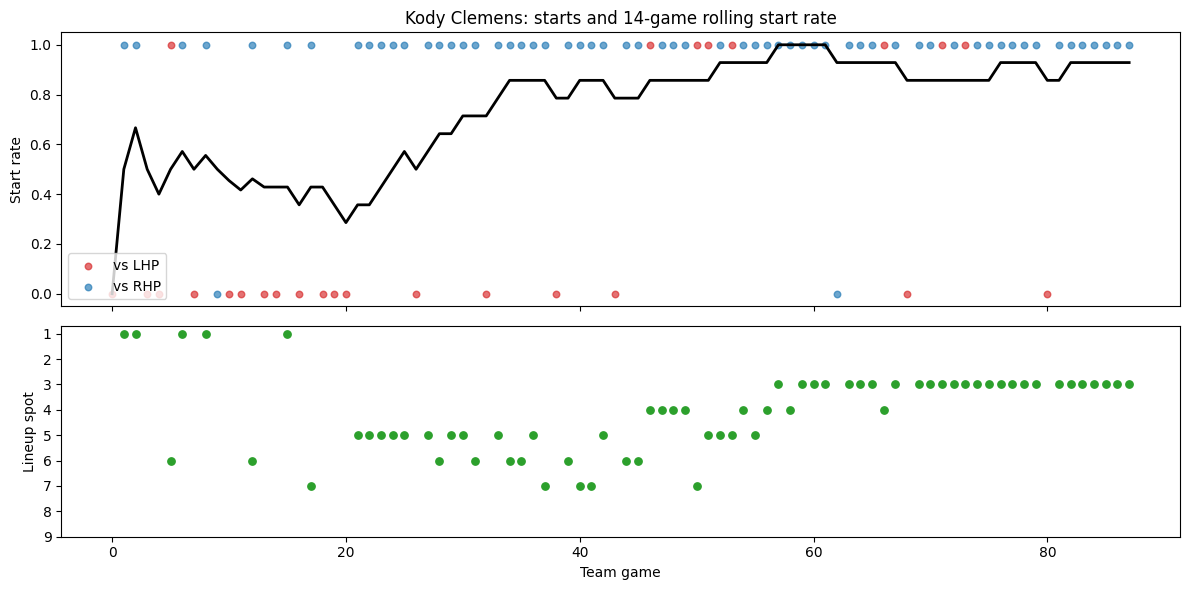

In [15]:
plot_player_usage(team_df, PLAYER)

## Interpretation Notes

- `regular_rest` means the player starts often enough to matter and missed starts occur in a relatively repeatable cadence.
- `platoon_candidate` requires enough games against both left- and right-handed starters and a large start-rate gap between those splits.
- `extended_absence_candidate` usually means injury, option, bereavement, suspension, or a role interruption rather than routine rest.
- `losing_time` compares recent usage against season-to-date usage and is meant to flag possible role changes.
- `part_time_or_rotation` is a broad bucket for partial playing time when there is not yet enough handedness evidence.
- `player_handedness_table(team_df, PLAYER)` summarizes starts and sits by opposing starter handedness.
- `missed_start_table(team_df, PLAYER)` shows the opposing starter and handedness on each individual day the selected player sat.
- `missed_episode_table(team_df, PLAYER)` groups consecutive sits and carries forward the scheduled opposing starters and their throwing hands.

For an all-team handedness scan, apply `add_pitcher_context(..., include_handedness=True)` team by team and then rerun `summarize_team_usage` on those enriched team frames. That fetches the prediction files plus one FanGraphs pitching table, so it is intentionally kept out of the default all-team cell.

In [16]:
handedness_usage_summary, team_games_with_handedness = build_handedness_usage_summary(team_games)

In [17]:
team_games

{'LAA':           date    lineup1         lineup2         lineup3      lineup4  \
 0   2026-03-26  Zach Neto      Mike Trout  Nolan Schanuel  Jorge Soler   
 1   2026-03-27  Zach Neto      Mike Trout  Nolan Schanuel  Jorge Soler   
 2   2026-03-28  Zach Neto      Mike Trout  Nolan Schanuel  Jorge Soler   
 3   2026-03-29  Zach Neto      Mike Trout  Nolan Schanuel  Jorge Soler   
 4   2026-03-30  Zach Neto      Mike Trout  Nolan Schanuel  Jorge Soler   
 ..         ...        ...             ...             ...          ...   
 83  2026-06-27  Zach Neto   Denzer Guzman  Nolan Schanuel  Jorge Soler   
 84  2026-06-28  Zach Neto   Denzer Guzman  Nolan Schanuel     Jo Adell   
 85  2026-06-29  Zach Neto   Denzer Guzman  Nolan Schanuel  Jorge Soler   
 86  2026-06-30  Zach Neto  Vaughn Grissom  Nolan Schanuel  Jorge Soler   
 87  2026-07-02  Zach Neto  Nolan Schanuel   Denzer Guzman  Jorge Soler   
 
            lineup5       lineup6         lineup7          lineup8  \
 0     Yoan Moncada  

In [18]:
handedness_usage_summary[
    ['team', 'player', 'games_vs_lhp', 'start_pct_vs_lhp', 'games_vs_rhp', 'start_pct_vs_rhp', 'usage_label']
][handedness_usage_summary['usage_label'].isin(['platoon_candidate'])].to_csv(f'platoon_candidates_{YEAR}.csv', index=False)